In [66]:
import requests
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By
import pandas as pd
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.common.keys import Keys
import time
import requests

In [68]:
options = webdriver.ChromeOptions()
driver = webdriver.Chrome()
actions = ActionChains(driver)
prices = []
names = []

url = "https://www.avito.ru/moskva_i_mo/ptitsy?cd=1&q=куры+несушки"
driver.get(url)
actions.send_keys(Keys.END).perform()
time.sleep(2)
actions.send_keys(Keys.END).perform()
time.sleep(3.643)
actions.send_keys(Keys.END).perform()
time.sleep(2.2342)
actions.send_keys(Keys.END).perform()



    

In [69]:
names = driver.find_elements(By.CLASS_NAME, "iva-item-titleStep-zichc")
names = [name.text for name in names] 

In [70]:
prices = driver.find_elements(By.CSS_SELECTOR, "meta[itemprop='price']")
prices = [int(price.get_attribute('content')) for price in prices]

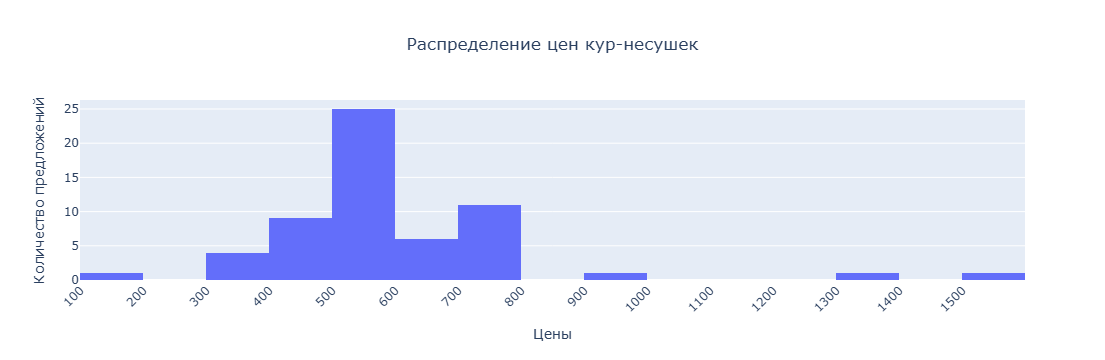

In [71]:
import plotly.express as px

prices = list(filter(lambda x: x >= 100, prices))
df = pd.DataFrame(prices, columns=['Price'])
fig = px.histogram(df, x='Price', nbins=16, title='Распределение цен кур-несушек')
fig.update_layout(title_x = 0.5, width = 700)
fig.update_yaxes(title='Количество предложений')
fig.update_xaxes(dtick=100, tickangle=-45, title='Цены') # c dtick явно подсказал дипсик
fig.show()